# RNN으로_금융앱리뷰_분석하기

In [1]:
!pip install numpy

In [2]:
from konlpy.tag import Mecab
mecab = Mecab()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten, Embedding
from tensorflow.keras.utils import to_categorical

2025-05-22 09:35:06.093402: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-22 09:35:06.095706: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-22 09:35:06.101041: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-22 09:35:06.115255: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747874106.146505    4333 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747874106.15

In [3]:
train_data = pd.read_csv('../05machine_learning/data/bank_app_reviews_train.csv')
train_data.head()

,리뷰일,평점,사용자리뷰,업체답변,은행명
0,2023-12-21,5,엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 ㅎㅎ 저도 쓰고있음!,NaN,하나
1,2025-02-17,1,Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...,안녕하세요. 신한은행입니다.\n먼저 SOL사용에 불편을 드려 죄송합니다.\n어플의 ...,신한
2,2024-07-26,5,서비스가 통합되어 있어서 점점 사용빈도가 높아지네요.,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민
3,2024-09-01,1,카드 충천이 안됌,"안녕하세요. 전민구 님, 토스팀입니다. 남겨주신 내용만으로는 겪고계신 불편사항의 자...",토스
4,2023-11-13,1,알뜰폰 인증이 안돼요.....,"안녕하세요 헤이모두들안녕님, 우리은행입니다. 먼저 이용에 불편을 드려 매우 죄송합니...",우리


특수문자 제거 함수
- 벡터화 하려면 특수문자 없어야함

In [4]:
import re

def clean_text(text):
    cleaned = re.sub(r'[^가-힣a-zA-Z0-9\s]','',text)  # 한글 영문 숫자 추출
    cleaned = re.sub(r'\s+',' ', cleaned) # 연속된 공백을 하나의 공백으로 줄임
    return cleaned.strip()

사용자 리뷰에서 특수문자 제거

In [5]:
train_data['사용자리뷰'] = train_data['사용자리뷰'].apply(clean_text)
train_data

,리뷰일,평점,사용자리뷰,업체답변,은행명
0,2023-12-21,5,엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음,NaN,하나
1,2025-02-17,1,Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...,안녕하세요. 신한은행입니다.\n먼저 SOL사용에 불편을 드려 죄송합니다.\n어플의 ...,신한
2,2024-07-26,5,서비스가 통합되어 있어서 점점 사용빈도가 높아지네요,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민
3,2024-09-01,1,카드 충천이 안됌,"안녕하세요. 전민구 님, 토스팀입니다. 남겨주신 내용만으로는 겪고계신 불편사항의 자...",토스
4,2023-11-13,1,알뜰폰 인증이 안돼요,"안녕하세요 헤이모두들안녕님, 우리은행입니다. 먼저 이용에 불편을 드려 매우 죄송합니...",우리
...,...,...,...,...,...
22241,2025-03-12,3,어플 시작오류가 가끔 나네요,안녕하세요 푸딩 고객님. 우리은행 우리WON뱅킹 이용에 불편을 드려 죄송합니다. 2...,우리
22242,2025-01-09,1,업데이트 후에 계좌이체하는 게 자주 튕겨요,안녕하세요 일월구일 고객님. 먼저 우리WON뱅킹 이용에 불편을 드려 죄송합니다. 보...,우리
22243,2023-07-07,5,굳굳굳,"Seung Woo Kim 고객님, 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로...",국민
22244,2024-10-10,5,오래시간 같이한 나의은행 든든합니다,안녕하세요 lee jeong seon (isate) 고객님. 칭찬 진심으로 감사드리...,우리


is_good 컬럼 추가, 평점 4이상은 긍정: 1, 3이하는 부정: 0

In [6]:
train_data['is_good'] = train_data['평점'].apply(lambda x: 1 if x >= 4 else 0)
train_data['is_good']

0        1
1        0
2        1
3        0
4        0
        ..
22241    0
22242    0
22243    1
22244    1
22245    0
Name: is_good, Length: 22246, dtype: int64

토큰화

In [7]:
mecab = Mecab()
mecab.morphs(train_data['사용자리뷰'][0])  # 형태로 단위로 분리

['엄',
 '빠',
 '폰',
 '에',
 '설치',
 '해',
 '드렸',
 '는데',
 '두',
 '분',
 '다',
 '쓰',
 '기',
 '편하',
 '다고',
 '하',
 '시',
 '네요',
 '저',
 '도',
 '쓰',
 '고',
 '있',
 '음']

전체 문장을 토큰화 한 후 tokenized_docs에 저장

In [8]:
tokenized_docs = train_data['사용자리뷰'].apply(mecab.morphs)

In [9]:
tokenized_docs[2]

['서비스',
 '가',
 '통합',
 '되',
 '어',
 '있',
 '어서',
 '점점',
 '사용',
 '빈도',
 '가',
 '높',
 '아',
 '지',
 '네요']

단어 인덱스 생성

In [10]:
token = Tokenizer(lower=False)
token.fit_on_texts(tokenized_docs)
print(len(token.word_index))

13010


문장 벡터화

In [11]:
x = token.texts_to_sequences(tokenized_docs)
print(x[0])

[5400, 1682, 170, 11, 159, 37, 2292, 14, 301, 184, 28, 45, 19, 106, 123, 1, 76, 15, 216, 5, 45, 2, 10, 64]


가장 긴 문장의 길이 구하기

In [12]:
max_length = max([len(i) for i in x]) + 1

가장 긴 길이에 맞춰서 패딩
* RNN의 경우 패딩을 post로 주는 것이 더 좋음, 단어가 앞, 0이 뒤에 붙음
* Transformer 계열은 위치 정보가 따로 있으므로 post, pre든 차이가 없음

In [13]:
X_padded = pad_sequences(x, maxlen=max_length, padding = 'post')
print(X_padded[0])

[5400 1682  170   11  159   37 2292   14  301  184   28   45   19  106
  123    1   76   15  216    5   45    2   10   64    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [14]:
X_padded.shape

(22246, 302)

In [15]:
y = train_data['is_good']
y.value_counts()

is_good
1    13240
0     9006
Name: count, dtype: int64

홀드아웃

In [16]:
!pip install scikit-learn

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_valid, y_train, y_valid= train_test_split(X_padded, y, test_size=0.3, stratify=y, random_state=42)

In [19]:
# 임베딩에 입력할 단어 수 추출
word_size = len(token.word_index)+1
print(word_size)

13011


# 양방향 RNN 네트워크를 이용해 텍스트 분석

In [20]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [21]:
birnn = Sequential()
birnn.add(Input(shape=(max_length, )))
birnn.add(Embedding(input_dim=word_size, output_dim=64))
birnn.add(Bidirectional(SimpleRNN(128, return_sequences=False, activation='tanh')))
birnn.add(Dense(32,activation='relu'))
birnn.add(Dropout(0.5))
birnn.add(Dense(1,activation='sigmoid'))
birnn.summary()

E0000 00:00:1747874116.026403    4333 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1747874116.027799    4333 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 302, 64)        │       832,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,369 (3.40 MB)

 Trainable params: 890,369 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.6888 - auc: 0.7365 - loss: 0.5700
Epoch 1: val_loss improved from inf to 0.32433, saving model to ./model/bank_app_review_birnn.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 37s 549ms/step - accuracy: 0.6902 - auc: 0.7382 - loss: 0.5686 - val_accuracy: 0.8711 - val_auc: 0.9348 - val_loss: 0.3243
Epoch 2/1000
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8874 - auc: 0.9360 - loss: 0.3111
Epoch 2: val_loss improved from 0.32433 to 0.27613, saving model to ./model/bank_app_review_birnn.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 31s 507ms/step - accuracy: 0.8875 - auc: 0.9360 - loss: 0.3110 - val_accuracy: 0.8948 - val_auc: 0.9501 - val_loss: 0.2761
Epoch 3/1000
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.9188 - auc: 0.9584 - loss: 0.2449
Epoch 3: val_loss improved from 0.27613 to 0.27520, saving model to ./model/bank_app_review_birnn.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 43s 715ms/step - accuracy: 0.9188 - auc: 0.9584 - loss: 0.2

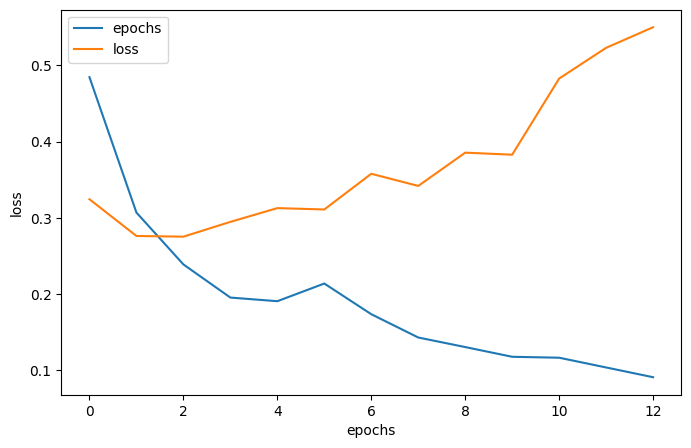

In [22]:
birnn.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_birnn.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                             save_best_only = True,
                             verbose = 1)
birnn_history = birnn.fit(X_train, y_train, epochs=1000, batch_size=256,
                          validation_data=(X_valid, y_valid),
                          callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8,5))
plt.plot(birnn_history.history['loss'])
plt.plot(birnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['epochs','loss'])
plt.show()
                             

In [23]:
print(birnn.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.8976 - auc: 0.9536 - loss: 0.2655
[0.2751959264278412, 0.8922684788703918, 0.9514846205711365]


In [24]:
pred = birnn.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step


array([[0.9939175 ],
       [0.94447774],
       [0.14681166],
       ...,
       [0.9797089 ],
       [0.06707273],
       [0.97107804]], dtype=float32)

In [25]:
y_valid

10299    1
11621    1
3616     0
3994     1
7488     0
        ..
10152    0
10710    1
5641     1
10113    0
14478    1
Name: is_good, Length: 6674, dtype: int64

In [26]:
pred = pd.DataFrame(pred)

In [27]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))

In [28]:
result = pd.concat([y_valid, pred], axis=1)
result.columns = ['is_good','pred']

In [29]:
result['pred'] = result['pred'].apply(lambda x: 1 if x>0.5 else 0)
result

,is_good,pred
0,1,1
1,1,1
2,0,0
3,1,1
4,0,0
...,...,...
6669,0,0
6670,1,1
6671,1,1
6672,0,0


In [30]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      2702
           1       0.93      0.89      0.91      3972

    accuracy                           0.89      6674
   macro avg       0.89      0.89      0.89      6674
weighted avg       0.89      0.89      0.89      6674



# LSTM과 CNN 조합 모델로 분석

In [31]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, GlobalMaxPooling1D

In [32]:
lstm_cnn = Sequential()

# CNN
lstm_cnn.add(Input(shape=(max_length, )))
lstm_cnn.add(Embedding(input_dim=word_size, output_dim=128))
lstm_cnn.add(Dropout(0.3))
lstm_cnn.add(Conv1D(128, 5, padding='valid', activation='relu'))
lstm_cnn.add(MaxPooling1D(pool_size=4))
lstm_cnn.add(Conv1D(128, 5, padding='valid', activation='relu'))
lstm_cnn.add(MaxPooling1D(pool_size=4))

# LSTM
lstm_cnn.add(Bidirectional(LSTM(256, return_sequences=True)))

# DNN
lstm_cnn.add(GlobalMaxPooling1D())
lstm_cnn.add(Dense(64, activation='relu'))
lstm_cnn.add(Dropout(0.3))
lstm_cnn.add(Dense(32, activation='relu'))
lstm_cnn.add(Dense(1, activation='sigmoid'))
lstm_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 302, 128)       │     1,665,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 302, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 298, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 74, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 70, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 17, 512)        │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,652,929 (10.12 MB)

 Trainable params: 2,652,929 (10.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.7273 - auc: 0.7640 - loss: 0.5379
Epoch 1: val_loss improved from inf to 0.28931, saving model to ./model/bank_app_review_lstm_cnn.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 446ms/step - accuracy: 0.7280 - auc: 0.7649 - loss: 0.5370 - val_accuracy: 0.8846 - val_auc: 0.9475 - val_loss: 0.2893
Epoch 2/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9060 - auc: 0.9546 - loss: 0.2565
Epoch 2: val_loss improved from 0.28931 to 0.26206, saving model to ./model/bank_app_review_lstm_cnn.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 54s 440ms/step - accuracy: 0.9060 - auc: 0.9546 - loss: 0.2565 - val_accuracy: 0.8927 - val_auc: 0.9553 - val_loss: 0.2621
Epoch 3/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9308 - auc: 0.9716 - loss: 0.1973
Epoch 3: val_loss did not improve from 0.26206
122/122 ━━━━━━━━━━━━━━━━━━━━ 54s 440ms/step - accuracy: 0.9308 - auc: 0.9716 - loss: 0.1973 - val_accuracy: 0.8938 - val_auc: 0

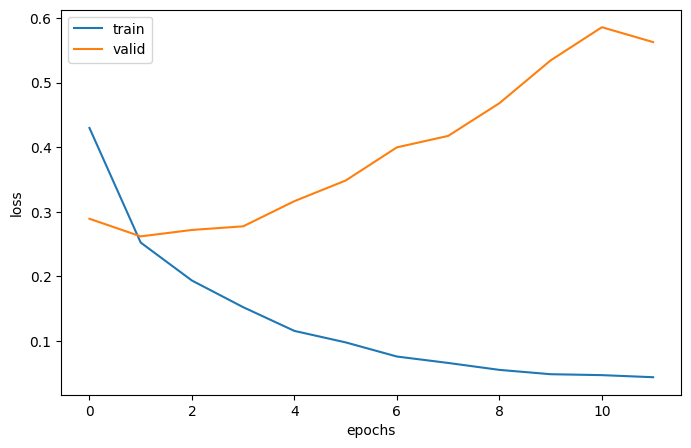

In [33]:
lstm_cnn.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_lstm_cnn.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                             save_best_only = True,
                             verbose = 1)
lstm_cnn_history = lstm_cnn.fit(X_train, y_train, epochs=1000, batch_size=128,
                          validation_data=(X_valid, y_valid),
                          callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8,5))
plt.plot(lstm_cnn_history.history['loss'])
plt.plot(lstm_cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','valid'])
plt.show()

In [49]:
print(lstm_cnn.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9007 - auc: 0.9559 - loss: 0.2729
[0.2799951732158661, 0.8948156833648682, 0.9540392756462097]


In [50]:
pred = lstm_cnn.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step


array([[0.99186546],
       [0.9957063 ],
       [0.00642764],
       ...,
       [0.99297297],
       [0.05254541],
       [0.985363  ]], dtype=float32)

In [51]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))

In [52]:
pred = pd.DataFrame(pred)

In [53]:
result = pd.concat([y_valid, pred], axis=1)
result.columns = ['is_good','pred']

In [54]:
result['pred'] = result['pred'].apply(lambda x: 1 if x>0.5 else 0)
result

,is_good,pred
0,1,1
1,1,1
2,0,0
3,1,1
4,0,0
...,...,...
6669,0,0
6670,1,1
6671,1,1
6672,0,0


In [40]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      2702
           1       0.93      0.89      0.91      3972

    accuracy                           0.89      6674
   macro avg       0.89      0.89      0.89      6674
weighted avg       0.89      0.89      0.89      6674



# Attention -> GPT
* RNN, LSTM 전체 문장을 기억
* 중요한 단어에만 집중

In [41]:
!pip install attention

In [42]:
from attention import Attention

In [45]:
from tensorflow.keras.layers import GlobalAveragePooling1D, LayerNormalization, MultiHeadAttention, Add
from tensorflow.keras.models import Model

In [47]:
inputs = Input(shape=(max_length, ))
x = Embedding(input_dim=word_size, output_dim=128)(inputs)
x = Dropout(0.3)(x)

# 양방향 LSTM
x = Bidirectional(LSTM(128, return_sequences=True))(x)

# 멀티헤드 어텐션
attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x,x)
attn_output = Dropout(0.3)(attn_output)
x = Add()([x, attn_output])
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)

# DNN
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)

# output
outputs = Dense(1, activation='sigmoid')(x)

attn_model = Model(inputs=inputs, outputs=outputs)
attn_model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 302)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 302, 128)  │  1,665,408 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 302, 128)  │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 302, 256)  │    263,168 │ dropout_7[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 302, 256)  │    263,168 │ bidirectional_3[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 302, 256)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 302, 256)  │          0 │ bidirectional_3[… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 302, 256)  │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,256 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │      2,080 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │         33 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,235,521 (8.53 MB)

 Trainable params: 2,235,521 (8.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9504 - auc: 0.9825 - loss: 0.1509
Epoch 1: val_loss improved from inf to 0.28784, saving model to ./model/bank_app_review_attn_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 51s 421ms/step - accuracy: 0.9504 - auc: 0.9825 - loss: 0.1510 - val_accuracy: 0.8879 - val_auc: 0.9511 - val_loss: 0.2878
Epoch 2/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9636 - auc: 0.9862 - loss: 0.1205
Epoch 2: val_loss did not improve from 0.28784
122/122 ━━━━━━━━━━━━━━━━━━━━ 51s 422ms/step - accuracy: 0.9636 - auc: 0.9862 - loss: 0.1206 - val_accuracy: 0.8878 - val_auc: 0.9474 - val_loss: 0.3059
Epoch 3/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9714 - auc: 0.9886 - loss: 0.1020
Epoch 3: val_loss did not improve from 0.28784
122/122 ━━━━━━━━━━━━━━━━━━━━ 53s 432ms/step - accuracy: 0.9714 - auc: 0.9885 - loss: 0.1021 - val_accuracy: 0.8770 - val_auc: 0.9362 - val_loss: 0.3526
Epoch 4/1000
122/122 ━━━━━━━━━━━━

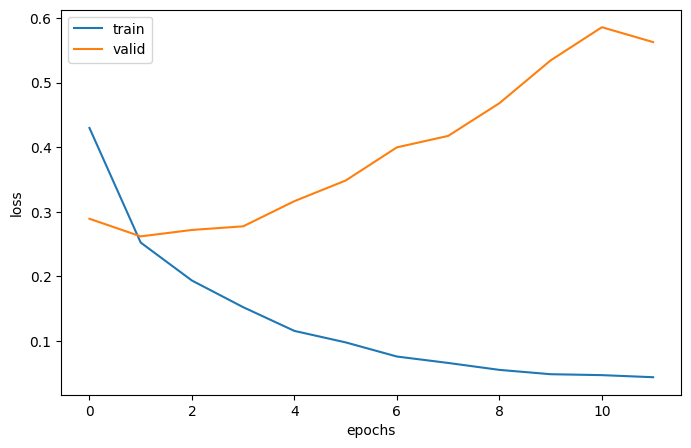

In [70]:
attn_model.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_attn_model.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                             save_best_only = True,
                             verbose = 1)
attn_model_history = lstm_cnn.fit(X_train, y_train, epochs=1000, batch_size=128,
                          validation_data=(X_valid, y_valid),
                          callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8,5))
plt.plot(lstm_cnn_history.history['loss'])
plt.plot(lstm_cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','valid'])
plt.show()

In [71]:
print(attn_model.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 49s 231ms/step - accuracy: 0.5859 - auc: 0.7692 - loss: 0.6716
[0.6691131591796875, 0.5951453447341919, 0.756415843963623]


In [63]:
pred = attn_model.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 46s 220ms/step


array([[0.5839342 ],
       [0.5853549 ],
       [0.57803524],
       ...,
       [0.5772407 ],
       [0.5806649 ],
       [0.5856924 ]], dtype=float32)

In [64]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))

In [65]:
pred = pd.DataFrame(pred)

In [66]:
result = pd.concat([y_valid, pred], axis=1)
result.columns = ['is_good','pred']

In [67]:
result['pred'] = result['pred'].apply(lambda x: 1 if x>0.5 else 0)
result

,is_good,pred
0,1,1
1,1,1
2,0,1
3,1,1
4,0,1
...,...,...
6669,0,1
6670,1,1
6671,1,1
6672,0,1


In [69]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2702
           1       0.60      1.00      0.75      3972

    accuracy                           0.60      6674
   macro avg       0.30      0.50      0.37      6674
weighted avg       0.35      0.60      0.44      6674



/home/ricky/miniforge3/envs/face/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ricky/miniforge3/envs/face/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ricky/miniforge3/envs/face/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i